# Alex Notebook

In [3]:
from pathlib import Path
Path("alex").mkdir(parents=True, exist_ok=True)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=33)
n = 800

course_track = rng.choice(["Web Dev", "Data Science", "Design"], size=n, p=[0.36, 0.32, 0.32])
weekly_login_hours = rng.normal(6, 2.5, size=n).clip(0, None).round(1)
forum_posts = rng.normal(4, 3, size=n).clip(0, None).round(0)
noise = rng.normal(0, 12, size=n)
track_bonus = pd.Series(course_track).map({"Web Dev": 0, "Design": 0, "Data Science": 6}).values
completion_pct = (20 + 8.5*weekly_login_hours + track_bonus + noise).clip(0, 100).round(1)

learners = pd.DataFrame({
    "learner_id": np.arange(1, n + 1),
    "course_track": course_track,
    "weekly_login_hours": weekly_login_hours,
    "forum_posts": forum_posts,
    "completion_pct": completion_pct,
})

## Alex's markdown cell — "Distribution of Weekly Login Hours":

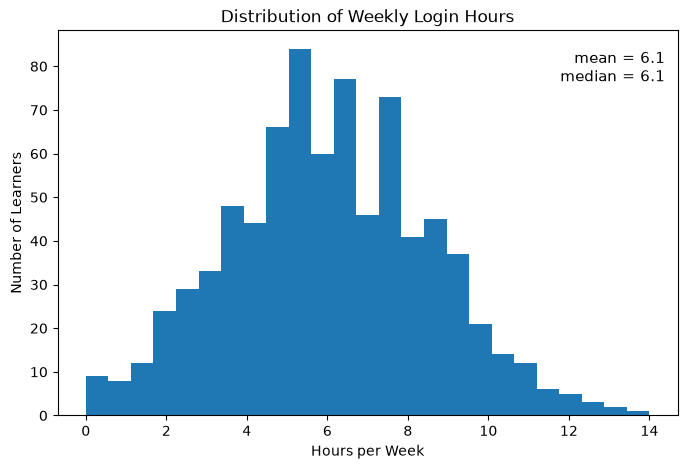

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(learners["weekly_login_hours"], bins=25)
ax.set_title("Distribution of Weekly Login Hours")
ax.set_xlabel("Hours per Week")
ax.set_ylabel("Number of Learners")
ax.annotate(
    f"mean = {learners['weekly_login_hours'].mean():.1f}\nmedian = {learners['weekly_login_hours'].median():.1f}",
    xy=(0.98, 0.95), xycoords="axes fraction", ha="right", va="top", fontsize=11,
)
fig.savefig("alex/chart_distribution.png")

## Alex's markdown cell — "Relationship: Course Track and Completion":

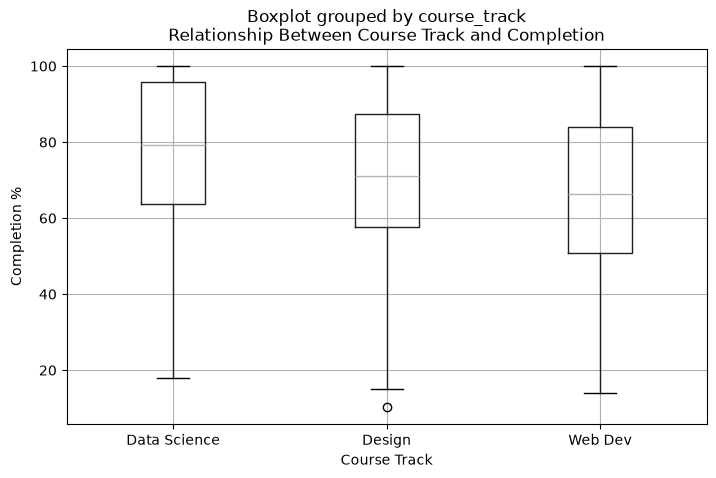

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
order = learners.groupby("course_track")["completion_pct"].mean().sort_values(ascending=False).index
colors = {"Data Science": "green", "Design": "yellow", "Web Dev": "red"}
learners.boxplot(column="completion_pct", by="course_track", ax=ax,
                  positions=range(len(order)))
ax.set_title("Relationship Between Course Track and Completion")
ax.set_xlabel("Course Track")
ax.set_ylabel("Completion %")
fig.savefig("alex/chart_relationship_track.png")

## Alex's markdown cell — "Login Hours and Completion":

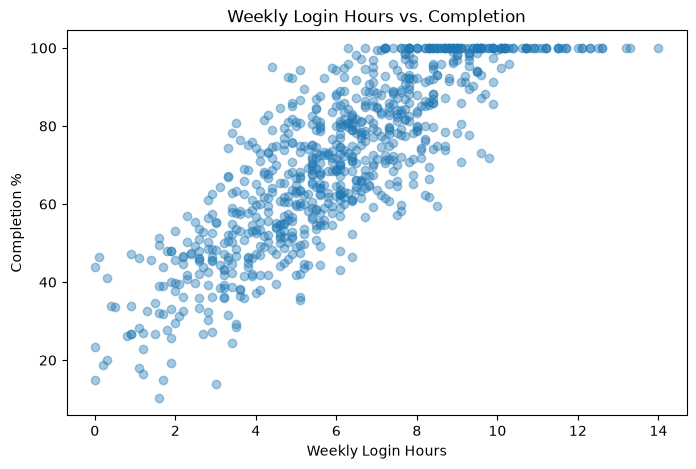

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(learners["weekly_login_hours"], learners["completion_pct"], alpha=0.4)
ax.set_title("Weekly Login Hours vs. Completion")
ax.set_xlabel("Weekly Login Hours")
ax.set_ylabel("Completion %")
fig.savefig("alex/chart_login_vs_completion.png")
plt.show()

## Alex's markdown cell — "Forum Activity":

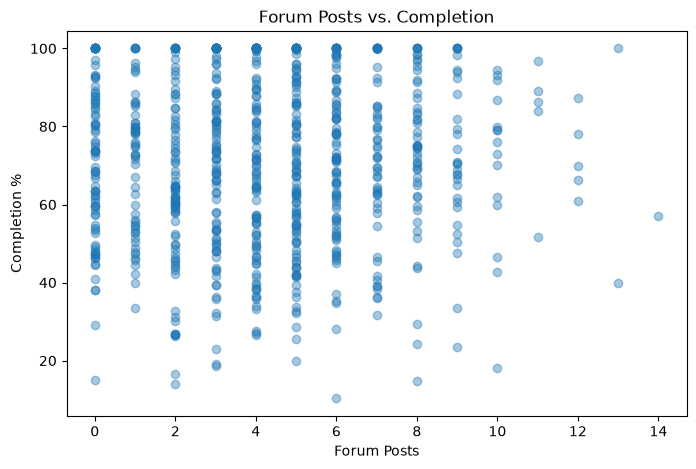

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(learners["forum_posts"], learners["completion_pct"], alpha=0.4)
ax.set_title("Forum Posts vs. Completion")
ax.set_xlabel("Forum Posts")
ax.set_ylabel("Completion %")
fig.savefig("alex/chart_forum_vs_completion.png")
plt.show()

## Alex's markdown cell — "Findings":

1. Weekly login hours cause higher completion — the platform should nudge learners to log in more.
2. Data Science learners have noticeably higher completion than the other two tracks.
3. The average completion rate across all learners is approximately 74%.

## Alex's markdown cell — "Conclusion": 

"This analysis shows that increasing login frequency is the clearest lever for improving course completion, and that course design differences between tracks are a secondary factor worth investigating."